# Problem Statement

The objective of this project is to analyze employee data to identify the key factors driving attrition and generate actionable business insights.

### Key Questions:

Why are employees leaving?

Which factors contribute most to attrition?

Can we identify high-risk employees?

# Import Libraries & Load Data

In [85]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [86]:
pip install pandas mysql-connector-python

Note: you may need to restart the kernel to use updated packages.


# Connect to database

In [87]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",          
    password="yourpassword",
    database="hr_employee_attirivation"
)

In [88]:
query = "SELECT * FROM new_hr_employee_attrition"

df = pd.read_sql(query, conn)

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,YearsSinceLastPromotion,YearsWithCurrManager,ExperienceGroup,RoleExperience,PromotionStatus,IncomeGroup,WorkLifeRisk,OvertimeRisk,DistanceCategory,SatisfactionLevel
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,0,5,5+ Years,Experienced,Recently Promoted,Medium,Poor,High,Near,High
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,1,7,5+ Years,Long-Term,Recently Promoted,Medium,Good,Low,Medium,Low
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,0,0,0-2 Years,New,Recently Promoted,Low,Good,High,Near,High
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,0,5+ Years,Long-Term,Moderate Gap,Low,Good,High,Near,High
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,2,2,2-5 Years,Experienced,Moderate Gap,Medium,Good,Low,Near,Low


## Data Understanding

In [89]:
print(df.shape)
print(df.columns)
print(df.info())

(1470, 43)
Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'ExperienceGroup', 'RoleExperience',
       'PromotionStatus', 'IncomeGroup', 'WorkLifeRisk', 'OvertimeRisk',
       'DistanceCategory', 'SatisfactionLevel'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 43 columns):
 #   Column  

### Check overall attrition rate

In [90]:
df['Attrition'] = df['Attrition'].map({'Yes':1, 'No':0})

In [91]:
df['Attrition'].value_counts(normalize=True)* 100

Attrition
0    83.877551
1    16.122449
Name: proportion, dtype: float64

### Feature Engineering

In [92]:
df['LowSalary'] = (df['MonthlyIncome'] < 3000).astype(int)
df['OverTimeFlag'] = (df['OverTime'] == 'Yes').astype(int)
df['NoPromotion'] = (df['YearsSinceLastPromotion'] > 3).astype(int)
df['LowSatisfaction'] = (df['JobSatisfaction'] <= 2).astype(int)

## Salary-based Attrition

In [93]:
df['SalaryBand']=pd.cut(df['MonthlyIncome'],
                         bins=[0,3000,7000,20000],
                         labels=['low','medium','high'])

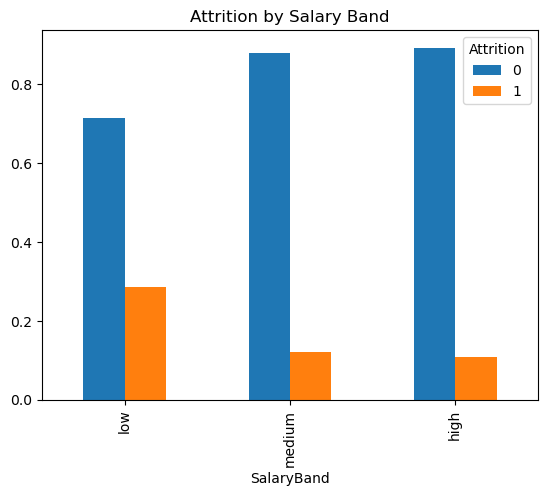

In [94]:
comp = df.groupby('SalaryBand')['Attrition'].value_counts(normalize=True).unstack()
comp.plot(kind='bar', title='Attrition by Salary Band')
plt.show()

### Insight

Employees in the low salary band have the highest attrition, showing they are more likely to leave the company.

Attrition decreases as salary increases, indicating better retention among higher-paid employees.

### Recommendation

Company should revise salary structure and ensure competitive pay to reduce attrition in low-salary employees to stay competitive in the market.

## Workload & Burnout based Attrition

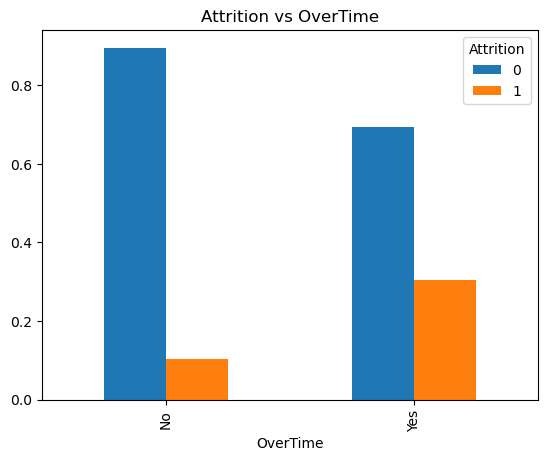

In [95]:
burnout=pd.crosstab(df['OverTime'],df['Attrition'],normalize='index')
burnout.plot(kind='bar',title='Attrition vs OverTime')
plt.show()

### Insight

Employees who work overtime show significantly higher attrition compared to those who do not.

The difference is substantial, indicating that overtime is a strong driver of employee turnover.

### Recommendation

Reduce excessive overtime

Introduce flexible working hours

## Employee Attrition Rate by Years at Company

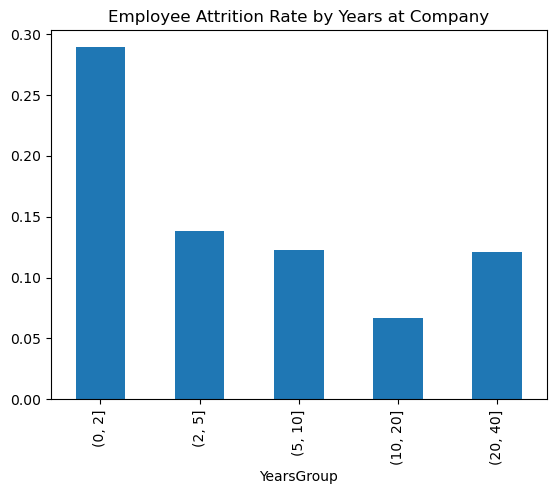

In [96]:
df['YearsGroup'] = pd.cut(
    df['YearsAtCompany'],
    bins=[0,2,5,10,20,40]
)

early = df.groupby('YearsGroup')['Attrition'].mean()
early.plot(kind='bar',title='Employee Attrition Rate by Years at Company')
plt.show()

### Insight

Employees with 0–2 years of experience have the highest attrition, showing early-stage employees are most likely to leave.

Attrition decreases as tenure increases, indicating that employees who stay longer become more stable.
### Recommendation

Focus on better onboarding and early engagement programs to reduce early-stage employee exits.

## Satisfaction based Attrition

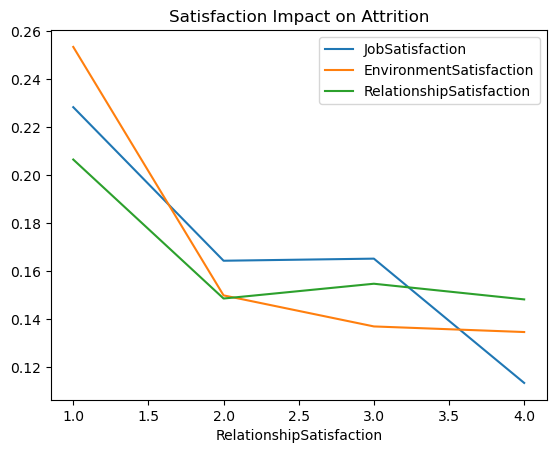

In [97]:
for col in ['JobSatisfaction','EnvironmentSatisfaction','RelationshipSatisfaction']:
    temp=df.groupby(col)['Attrition'].mean()
    temp.plot(label=col)
plt.legend()
plt.title("Satisfaction Impact on Attrition")
plt.show()

### Insight
Low satisfaction strongly correlates with attrition
### Recommendation
Conduct regular employee feedback surveys

Improve workplace culture and management quality

## Career Growth & Promotion based Attrition

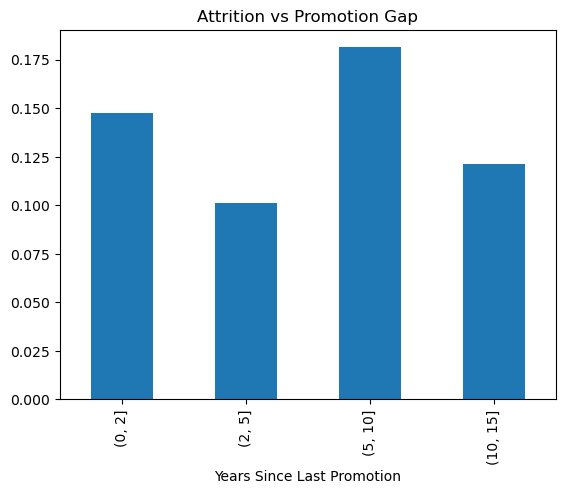

In [98]:
df['Years Since Last Promotion'] = pd.cut(
    df['YearsSinceLastPromotion'],
    bins=[0,2,5,10,15]
)
promo = df.groupby('Years Since Last Promotion')['Attrition'].mean()

promo.plot(kind='bar',title='Attrition vs Promotion Gap')
plt.show()

### Insight

Attrition increases as the promotion gap grows, with highest exits in the 5–10 years without promotion group.

### Recommendation
Introduce regular promotion cycles and career growth plans to prevent employees from feeling stuck.

## Department based Attrition

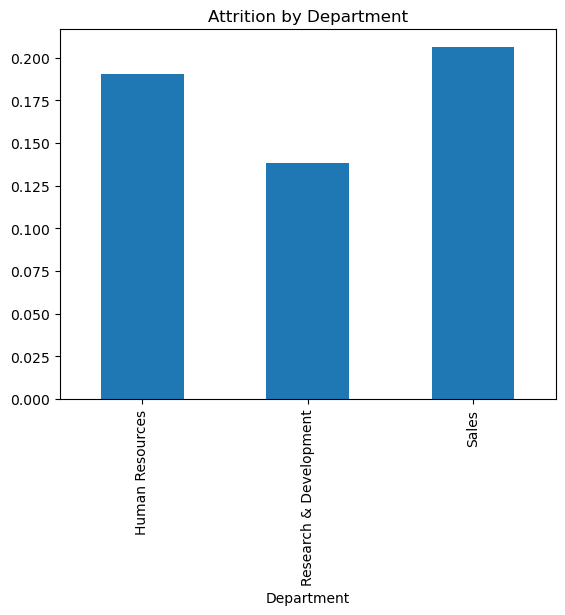

In [99]:
dept=df.groupby('Department')['Attrition'].mean()
dept.plot(kind='bar', title='Attrition by Department')
plt.show()

### Insight

Sales department has the highest attrition, while Research & Development shows the lowest employee exits.

### Recommendation

Focus on reducing workload and improving incentives in Sales to improve retention.

## Attrition Rate by Distance to Office

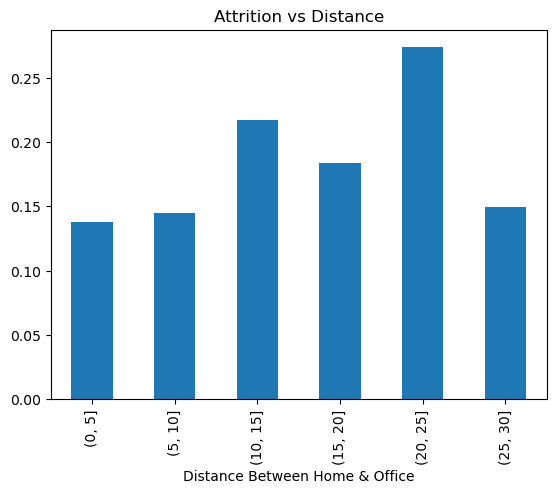

In [100]:
df['Distance Between Home & Office']=pd.cut(df['DistanceFromHome'],
                      bins=[0,5,10,15,20,25,30])
dist = df.groupby('Distance Between Home & Office')['Attrition'].mean()
dist.plot(kind='bar',title='Attrition vs Distance')
plt.show()

### Insight

Attrition increases with longer commute distance, peaking around 20–25 km, indicating travel fatigue impacts retention.

### Recommendation

Offer remote work, relocation support, or travel benefits to employees with long commutes to reduce attrition.

## Multi-Factor Risk Model

In [101]:
df['RiskScore'] = df[['LowSalary','OverTimeFlag','NoPromotion','LowSatisfaction']].sum(axis=1)

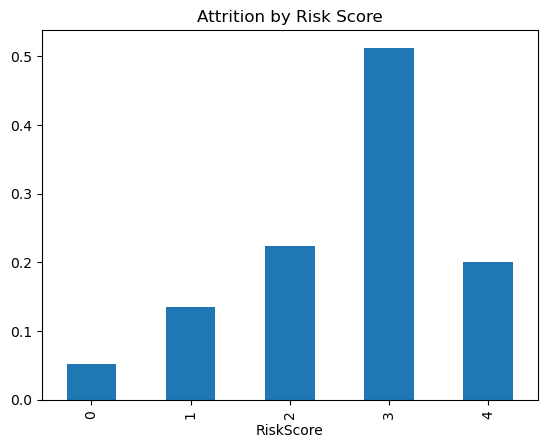

In [102]:
risk = df.groupby('RiskScore')['Attrition'].mean()
risk.plot(kind='bar', title='Attrition by Risk Score')
plt.show()

## Top Factors Driving Employee Attrition

In [103]:
important_cols = [
    'Attrition',
    'RiskScore',
    'LowSalary',
    'OverTimeFlag',
    'NoPromotion',
    'LowSatisfaction',
    'YearsAtCompany',
    'YearsSinceLastPromotion',
    'DistanceFromHome'
]

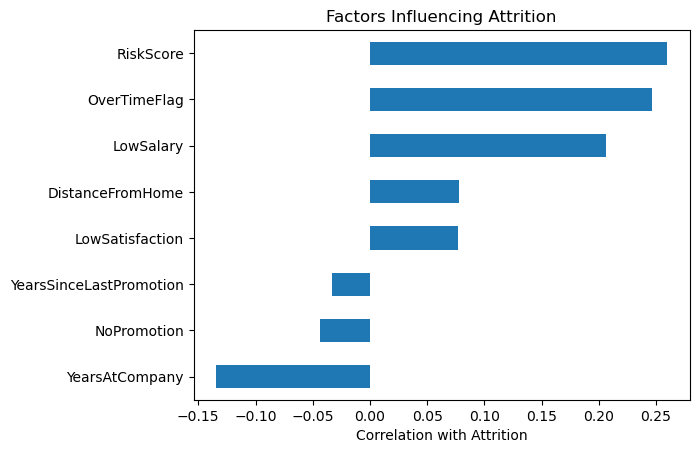

In [104]:
corr = df[important_cols].corr()['Attrition'].drop('Attrition').sort_values()

corr.plot(kind='barh', title='Factors Influencing Attrition')

plt.xlabel('Correlation with Attrition')
plt.show()

### Insight

Overtime, low salary, and overall risk score are the strongest drivers of attrition, while employees with more years at the company are less likely to leave.

### Recommendation

Reduce overtime workload, improve compensation, and focus on retaining experienced employees to effectively lower attrition.